# How to improve concepts ?

With good concept, the potential increase in recall@1 is huge. Jumping from 33% to 73% ! -> We have to direct our efforts to better concept predition
Strategies :

    - A. Train longer on fine-tuned embeddings 
    - B. Train to predict elephant SEEK (instead of subject SEEK)
    - C. Tim’s take : Aggregate predicted subject SEEK into elephant SEEK at evaluation time. Is it realistic to do it in the Gallery ? in the query set ? Within the same encounter only in the query set ?

In [1]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from backbone import Backbone
from concept_head import ConceptHead
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled


from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
import torch.nn as nn


/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
code = 'Improve_concept'

dataset = EleHandler(subset='IDI_6')
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=512, shuffle=False)

In [3]:

MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)

r = Retrieval(experiment_code=code)
r.evaluate_model(MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

evaluating backbone
Train Recalls:
Recall@1: 53.15%
Recall@5: 75.01%
Recall@10: 82.89%
Recall@20: 89.10%
Recall@100: 97.83%
Test Recalls:
Recall@1: 38.39%
Recall@5: 54.23%
Recall@10: 60.40%
Recall@20: 66.57%
Recall@100: 83.70%


In [4]:
concept_head = ConceptHead(lr=0.001, loss=F.mse_loss, print_every=1, experiment_code = code)

MD_finetuned.freeze()
concept_head.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=50)
concept_head.test(test_loader, backbone = MD_finetuned)

r.evaluate_model(concept_head, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

wandb: Currently logged in as: antoinesalaun (antoinesalaun-massachusetts-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Training ConceptHead for 50 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
output shape torch.Size([512, 63]) labels shape torch.Size([512, 63])
output shape torch.Size([512, 63]) labels shape torch.Size([512, 63])
output shape torch.Size([512, 63]) labels shape torch.Size([512, 63])
output shape torch.Size([445, 63]) labels shape torch.Size([445, 63])
output shape torch.Size([512, 63]) labels shape torch.Size([512, 63])
output shape torch.Size([512, 63]) labels shape torch.Size([512, 63])
output shape torch.Size([289, 63]) labels shape torch.Size([289, 63])
Epoch 1/50 - Train Loss: 0.2786, Val Loss: 0.1958 - Train Acc: 37.09%, Val Acc: 53.85% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 29.27%, Val left ear: 43.52% - Train right ear: 27.81%, Val right ear: 41.09%
output shape torch.Size([512, 63]) labels shape torch.Size([512, 63])
output shape torch.Size([512, 63]) labels shape torch.Size([512, 63])
output sha

KeyboardInterrupt: 

## Let's try learning the actual ele_SEEK_code

In [15]:
code = 'Improve_concept'
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.freeze()

r = Retrieval(experiment_code=code)

concept_head = ConceptHead(lr=0.001, loss=F.mse_loss, print_every=1, experiment_code = code)
concept_head.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=50, predict_ele_SEEK = True)
concept_head.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = True)

r.evaluate_model(concept_head, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

Training ConceptHead for 50 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/50 - Train Loss: 0.2691, Val Loss: 0.1803 - Train Acc: 40.31%, Val Acc: 60.48% - Train whole-code: 0.00%, Val whole-code: 0.12%
Epoch 2/50 - Train Loss: 0.1554, Val Loss: 0.1205 - Train Acc: 65.81%, Val Acc: 72.72% - Train whole-code: 0.36%, Val whole-code: 0.49%
Epoch 3/50 - Train Loss: 0.1089, Val Loss: 0.1006 - Train Acc: 75.25%, Val Acc: 75.85% - Train whole-code: 1.27%, Val whole-code: 1.06%
Epoch 4/50 - Train Loss: 0.0909, Val Loss: 0.0934 - Train Acc: 78.62%, Val Acc: 76.94% - Train whole-code: 2.52%, Val whole-code: 1.26%
Epoch 5/50 - Train Loss: 0.0822, Val Loss: 0.0903 - Train Acc: 80.20%, Val Acc: 77.41% - Train whole-code: 3.23%, Val whole-code: 1.52%
Epoch 6/50 - Train Loss: 0.0767, Val Loss: 0.0887 - Train Acc: 81.21%, Val Acc: 77.54% - Train whole-code: 4.03%, Val whole-code: 1.75%
Epoch 7/50 - Train Loss: 0.0727, Val Loss: 0.0879 - Trai

100%|██████████| 4/4 [00:13<00:00,  3.38s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:07<00:00,  2.66s/it]


Train Recalls:
Recall@1: 42.20%
Recall@5: 58.20%
Recall@10: 66.68%
Recall@20: 76.78%
Recall@100: 91.52%
Test Recalls:
Recall@1: 1.98%
Recall@5: 4.57%
Recall@10: 6.47%
Recall@20: 8.91%
Recall@100: 22.85%


## Bigger Network

In [ ]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.freeze()

r = Retrieval(experiment_code=code)

concept_head = ConceptHead(lr=0.001, loss=F.mse_loss, print_every=1, experiment_code = code)

concept_head.layer = nn.Sequential(
            nn.Linear(concept_head.input_dim, 200), 
            nn.LeakyReLU(),
            nn.Linear(200, 63), 
            nn.Sigmoid()
            ).to('cuda')

concept_head.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=50, predict_ele_SEEK = True)
concept_head.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = True)

r.evaluate_model(concept_head, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


Training ConceptHead for 50 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/50 - Train Loss: 0.2271, Val Loss: 0.1416 - Train Acc: 47.16%, Val Acc: 69.89% - Train whole-code: 0.06%, Val whole-code: 0.31%
Epoch 2/50 - Train Loss: 0.1152, Val Loss: 0.0980 - Train Acc: 74.67%, Val Acc: 76.46% - Train whole-code: 1.01%, Val whole-code: 1.01%
Epoch 3/50 - Train Loss: 0.0841, Val Loss: 0.0891 - Train Acc: 79.51%, Val Acc: 77.49% - Train whole-code: 2.78%, Val whole-code: 1.52%
Epoch 4/50 - Train Loss: 0.0754, Val Loss: 0.0874 - Train Acc: 81.17%, Val Acc: 77.77% - Train whole-code: 3.33%, Val whole-code: 0.90%
Epoch 5/50 - Train Loss: 0.0700, Val Loss: 0.0865 - Train Acc: 82.53%, Val Acc: 78.11% - Train whole-code: 4.33%, Val whole-code: 1.13%
Epoch 6/50 - Train Loss: 0.0652, Val Loss: 0.0858 - Train Acc: 83.86%, Val Acc: 78.13% - Train whole-code: 6.74%, Val whole-code: 1.76%
Epoch 7/50 - Train Loss: 0.0611, Val Loss: 0.0856 - Trai

100%|██████████| 4/4 [00:12<00:00,  3.17s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:08<00:00,  2.96s/it]


Train Recalls:
Recall@1: 63.05%
Recall@5: 73.65%
Recall@10: 80.01%
Recall@20: 89.35%
Recall@100: 98.28%
Test Recalls:
Recall@1: 2.51%
Recall@5: 3.81%
Recall@10: 4.65%
Recall@20: 6.17%
Recall@100: 18.51%


## Other loss

In [17]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.freeze()

r = Retrieval(experiment_code=code)

concept_head = ConceptHead(lr=0.001, loss=nn.CrossEntropyLoss(), print_every=1, experiment_code = code)

concept_head.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=50, predict_ele_SEEK = True)
concept_head.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = True)

r.evaluate_model(concept_head, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

Training ConceptHead for 50 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/50 - Train Loss: 65.6348, Val Loss: 63.2449 - Train Acc: 39.08%, Val Acc: 61.18% - Train whole-code: 0.00%, Val whole-code: 0.25%
Epoch 2/50 - Train Loss: 62.4951, Val Loss: 61.1918 - Train Acc: 66.27%, Val Acc: 73.54% - Train whole-code: 0.45%, Val whole-code: 0.56%
Epoch 3/50 - Train Loss: 60.7832, Val Loss: 60.2625 - Train Acc: 75.71%, Val Acc: 76.23% - Train whole-code: 1.43%, Val whole-code: 0.69%
Epoch 4/50 - Train Loss: 59.9482, Val Loss: 59.8460 - Train Acc: 78.63%, Val Acc: 77.13% - Train whole-code: 2.19%, Val whole-code: 0.69%
Epoch 5/50 - Train Loss: 59.5190, Val Loss: 59.6422 - Train Acc: 79.84%, Val Acc: 77.55% - Train whole-code: 3.04%, Val whole-code: 0.62%
Epoch 6/50 - Train Loss: 59.2669, Val Loss: 59.5318 - Train Acc: 80.49%, Val Acc: 77.88% - Train whole-code: 3.34%, Val whole-code: 0.82%
Epoch 7/50 - Train Loss: 59.0967, Val Loss: 

100%|██████████| 4/4 [00:13<00:00,  3.40s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:07<00:00,  2.64s/it]


Train Recalls:
Recall@1: 13.73%
Recall@5: 25.85%
Recall@10: 33.42%
Recall@20: 45.99%
Recall@100: 71.48%
Test Recalls:
Recall@1: 1.52%
Recall@5: 4.27%
Recall@10: 5.86%
Recall@20: 10.51%
Recall@100: 29.32%


## Ele-SEEK, Bigger network, dropout and cross-entropy

In [25]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.freeze()

r = Retrieval(experiment_code=code)
big = nn.Sequential(
            nn.Linear(768 * 3, 256), 
            nn.Dropout(0.5),
            nn.LeakyReLU(),
            nn.Linear(256, 63)
            )

concept_head = ConceptHead(lr=0.001, loss=nn.CrossEntropyLoss(), print_every=1, experiment_code = code, architecture=big)

concept_head.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=50, predict_ele_SEEK = True)
concept_head.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = True)

r.evaluate_model(concept_head, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Training ConceptHead for 50 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
output shape torch.Size([512, 63]) labels shape torch.Size([512, 63])
output shape torch.Size([512, 63]) labels shape torch.Size([512, 63])
output shape torch.Size([512, 63]) labels shape torch.Size([512, 63])
output shape torch.Size([445, 63]) labels shape torch.Size([445, 63])


KeyboardInterrupt: 

## Back to subject SEEK-codes, learning with 3 networks, one for each ear and one for the general image

In [10]:
SEEK.test_separate_and_reconstruct()

B00T__E8000-0000X0_S00
Original one-hot :
 tensor([1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
        0., 1., 0., 1., 0., 0., 1., 0., 0.])
parsed from one hot B00T__E8000-0000X0_S00
Whole one-hot vector:
 tensor([[1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1.,
         0., 0., 1., 0., 0.]])
Left one-hot vector:
 tensor([[1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
         0., 0.]])
Right one-hot vector:
 tensor([[0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
         0., 0.]])
reconstructed_one_hot tensor([1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.,

In [ ]:
from concept_head_tunneled import ConceptHeadTunneled



MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.freeze()

r = Retrieval(experiment_code=code)

small = [
        nn.Sequential(nn.Linear(768, 23)),
        nn.Sequential(nn.Linear(768, 20)),
        nn.Sequential(nn.Linear(768, 20))
]

concept_head_t = ConceptHeadTunneled(lr=0.001, loss=F.mse_loss, print_every=1, experiment_code = code, architecture = small)

concept_head_t.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)

concept_head_t.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)

r.evaluate_model(concept_head_t, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 1.7041, Val Loss: 1.2560 - Train Acc: 31.39%, Val Acc: 43.52% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 27.19%, Val left ear: 32.68% - Train right ear: 21.05%, Val right ear: 32.59%
Epoch 2/20 - Train Loss: 1.0990, Val Loss: 1.0181 - Train Acc: 49.71%, Val Acc: 58.11% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 39.16%, Val left ear: 47.28% - Train right ear: 42.74%, Val right ear: 48.43%
Epoch 3/20 - Train Loss: 0.8621, Val Loss: 0.8795 - Train Acc: 59.57%, Val Acc: 60.21% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 49.63%, Val left ear: 48.74% - Train right ear: 51.16%, Val right ear: 49.10%
Epoch 4/20 - Train Loss: 0.7204, Val Loss: 0.7700 - Train Acc: 61.67%, Val Acc: 60.73% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 51.53%, Val left ear: 

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc_avg,▁▄▅▆▆▆▆▇▇▇▇▇▇███████
train_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc_avg,▁▅▆▆▆▆▇▇▇▇██████████
val_loss,█▆▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch,20
train_acc_avg,0.78172
train_loss,0.28453
val_acc_avg,0.67906
val_loss,0.45419


evaluating concept head  
collecting concepts from concept head


100%|██████████| 4/4 [00:14<00:00,  3.58s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:09<00:00,  3.27s/it]


Train Recalls:
Recall@1: 0.86%
Recall@5: 3.89%
Recall@10: 6.71%
Recall@20: 11.11%
Recall@100: 34.28%
Test Recalls:
Recall@1: 0.84%
Recall@5: 2.89%
Recall@10: 4.27%
Recall@20: 8.83%
Recall@100: 33.82%


In [ ]:

MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.freeze()

r = Retrieval(experiment_code=code)

small_with_sigmmoid = [
                nn.Sequential(
                        nn.Linear(768, 23),
                        nn.Sigmoid()
                        ),
                nn.Sequential(
                        nn.Linear(768, 20),
                        nn.Sigmoid()
                        ),
                nn.Sequential(
                        nn.Linear(768, 20),
                        nn.Sigmoid()
                        )
]

concept_head_t = ConceptHeadTunneled(lr=0.001, loss=F.mse_loss, print_every=1, experiment_code = code, architecture = small_with_sigmmoid)


concept_head_t.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)

concept_head_t.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)

r.evaluate_model(concept_head_t, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 0.7448, Val Loss: 0.6277 - Train Acc: 33.63%, Val Acc: 55.47% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 25.22%, Val left ear: 46.30% - Train right ear: 24.21%, Val right ear: 42.61%
Epoch 2/20 - Train Loss: 0.5961, Val Loss: 0.5306 - Train Acc: 58.86%, Val Acc: 64.44% - Train whole-code: 0.06%, Val whole-code: 0.44% - Train left ear: 49.65%, Val left ear: 52.44% - Train right ear: 48.19%, Val right ear: 52.90%
Epoch 3/20 - Train Loss: 0.5112, Val Loss: 0.4781 - Train Acc: 66.49%, Val Acc: 67.40% - Train whole-code: 0.30%, Val whole-code: 1.08% - Train left ear: 56.35%, Val left ear: 56.78% - Train right ear: 56.07%, Val right ear: 55.87%
Epoch 4/20 - Train Loss: 0.4602, Val Loss: 0.4454 - Train Acc: 69.34%, Val Acc: 68.64% - Train whole-code: 0.80%, Val whole-code: 0.57% - Train left ear: 59.68%, Val left ear: 

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc_avg,▁▅▆▇▇▇▇▇▇███████████
train_loss,█▆▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc_avg,▁▅▇▇▇███████████████
val_loss,█▆▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch,20
train_acc_avg,0.76601
train_loss,0.27991
val_acc_avg,0.7043
val_loss,0.33668


evaluating concept head  
collecting concepts from concept head


100%|██████████| 4/4 [00:12<00:00,  3.20s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:08<00:00,  2.68s/it]


Train Recalls:
Recall@1: 1.01%
Recall@5: 3.13%
Recall@10: 5.45%
Recall@20: 10.10%
Recall@100: 31.10%
Test Recalls:
Recall@1: 0.69%
Recall@5: 2.97%
Recall@10: 5.18%
Recall@20: 9.75%
Recall@100: 32.98%


## Bigger networks, with dropout

In [4]:
from concept_head_tunneled import ConceptHeadTunneled

MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.freeze()


r = Retrieval(experiment_code=code)

bigger = [
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(256, 23)
                        ),
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(256, 20)
                        ),
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(256, 20)
                        )
]

concept_head_t = ConceptHeadTunneled(lr=0.001, loss=F.mse_loss, print_every=1, experiment_code = code, architecture = bigger)

concept_head_t.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_head_t.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)

r.evaluate_model(concept_head_t, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 0.9307, Val Loss: 0.4792 - Train Acc: 38.97%, Val Acc: 65.99% - Train whole-code: 0.00%, Val whole-code: 0.43% - Train left ear: 35.34%, Val left ear: 54.08% - Train right ear: 37.51%, Val right ear: 54.78%
Epoch 2/20 - Train Loss: 0.5649, Val Loss: 0.3972 - Train Acc: 63.52%, Val Acc: 67.94% - Train whole-code: 0.05%, Val whole-code: 0.43% - Train left ear: 52.90%, Val left ear: 56.84% - Train right ear: 54.24%, Val right ear: 55.95%
Epoch 3/20 - Train Loss: 0.4395, Val Loss: 0.3723 - Train Acc: 67.93%, Val Acc: 68.44% - Train whole-code: 0.50%, Val whole-code: 0.43% - Train left ear: 57.65%, Val left ear: 57.75% - Train right ear: 58.04%, Val right ear: 56.60%
Epoch 4/20 - Train Loss: 0.3985, Val Loss: 0.3712 - Train Acc: 69.97%, Val Acc: 69.08% - Train whole-code: 0.97%, Val whole-code: 1.23% - Train left ear: 60.60%, Val left ear: 

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc_avg,▁▅▅▆▆▆▇▇▇▇▇▇▇███████
train_loss,█▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc_avg,▁▄▅▅▆▇▇▇▇▇▇█████████
val_loss,█▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
train_acc_avg,0.84047
train_loss,0.21926
val_acc_avg,0.70609
val_loss,0.33042


evaluating concept head  
collecting concepts from concept head


100%|██████████| 4/4 [00:13<00:00,  3.40s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:08<00:00,  2.78s/it]


Train Recalls:
Recall@1: 0.35%
Recall@5: 3.43%
Recall@10: 5.25%
Recall@20: 9.09%
Recall@100: 28.52%
Test Recalls:
Recall@1: 1.29%
Recall@5: 2.89%
Recall@10: 4.72%
Recall@20: 9.06%
Recall@100: 31.15%


In [5]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.freeze()


r = Retrieval(experiment_code=code)

bigger_with_sigmoid = [
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(256, 23),
                        nn.Sigmoid()
                        ),
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(256, 20),
                        nn.Sigmoid()
                        ),
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(256, 20),
                        nn.Sigmoid()
                        )
]

concept_head_t = ConceptHeadTunneled(lr=0.001, loss=F.mse_loss, print_every=1, experiment_code = code, architecture = bigger_with_sigmoid)

concept_head_t.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_head_t.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)

r.evaluate_model(concept_head_t, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 0.6977, Val Loss: 0.5462 - Train Acc: 43.47%, Val Acc: 65.76% - Train whole-code: 0.00%, Val whole-code: 0.07% - Train left ear: 30.89%, Val left ear: 53.53% - Train right ear: 34.82%, Val right ear: 52.24%
Epoch 2/20 - Train Loss: 0.5154, Val Loss: 0.4389 - Train Acc: 64.67%, Val Acc: 68.39% - Train whole-code: 0.05%, Val whole-code: 0.20% - Train left ear: 50.55%, Val left ear: 57.18% - Train right ear: 52.40%, Val right ear: 56.80%
Epoch 3/20 - Train Loss: 0.4254, Val Loss: 0.3897 - Train Acc: 68.52%, Val Acc: 69.22% - Train whole-code: 0.20%, Val whole-code: 0.80% - Train left ear: 56.25%, Val left ear: 58.43% - Train right ear: 57.72%, Val right ear: 58.23%
Epoch 4/20 - Train Loss: 0.3747, Val Loss: 0.3568 - Train Acc: 70.58%, Val Acc: 69.80% - Train whole-code: 0.76%, Val whole-code: 1.44% - Train left ear: 59.65%, Val left ear: 

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc_avg,▁▅▆▆▆▆▆▇▇▇▇▇▇▇██████
train_loss,█▅▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc_avg,▁▄▅▆▆▇▇▇████████████
val_loss,█▅▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
train_acc_avg,0.81528
train_loss,0.21558
val_acc_avg,0.71282
val_loss,0.31298


evaluating concept head  
collecting concepts from concept head


100%|██████████| 4/4 [00:12<00:00,  3.13s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:08<00:00,  2.75s/it]


Train Recalls:
Recall@1: 1.31%
Recall@5: 3.89%
Recall@10: 5.81%
Recall@20: 9.64%
Recall@100: 28.27%
Test Recalls:
Recall@1: 0.76%
Recall@5: 2.59%
Recall@10: 4.49%
Recall@20: 7.92%
Recall@100: 29.93%


In [6]:
from concept_head_tunneled import ConceptHeadTunneled

MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.freeze()


r = Retrieval(experiment_code=code)

bigger = [
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(256, 23)
                        ),
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(256, 20)
                        ),
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(256, 20)
                        )
]

concept_head_t = ConceptHeadTunneled(lr=0.001, loss=nn.CrossEntropyLoss(), print_every=1, experiment_code = code, architecture = bigger)

concept_head_t.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_head_t.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)

r.evaluate_model(concept_head_t, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 47.1654, Val Loss: 43.4494 - Train Acc: 49.12%, Val Acc: 67.57% - Train whole-code: 0.00%, Val whole-code: 0.49% - Train left ear: 37.91%, Val left ear: 57.63% - Train right ear: 36.85%, Val right ear: 53.81%
Epoch 2/20 - Train Loss: 43.2836, Val Loss: 42.2732 - Train Acc: 68.66%, Val Acc: 69.29% - Train whole-code: 0.41%, Val whole-code: 0.95% - Train left ear: 58.24%, Val left ear: 59.15% - Train right ear: 56.65%, Val right ear: 57.74%
Epoch 3/20 - Train Loss: 41.9518, Val Loss: 41.4909 - Train Acc: 70.71%, Val Acc: 69.80% - Train whole-code: 1.12%, Val whole-code: 2.12% - Train left ear: 61.26%, Val left ear: 59.94% - Train right ear: 59.69%, Val right ear: 58.56%
Epoch 4/20 - Train Loss: 40.8392, Val Loss: 40.7525 - Train Acc: 72.34%, Val Acc: 70.11% - Train whole-code: 1.78%, Val whole-code: 2.45% - Train left ear: 63.01%, Val le

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc_avg,▁▅▅▆▆▆▆▆▇▇▇▇▇▇▇█████
train_loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val_acc_avg,▁▄▅▆▆▇▇▇████████████
val_loss,█▅▄▂▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂
epoch,20
train_acc_avg,0.84332
train_loss,35.33493
val_acc_avg,0.71066
val_loss,40.81777


evaluating concept head  
collecting concepts from concept head


100%|██████████| 4/4 [00:13<00:00,  3.28s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:08<00:00,  2.68s/it]


Train Recalls:
Recall@1: 1.01%
Recall@5: 3.53%
Recall@10: 5.50%
Recall@20: 9.74%
Recall@100: 30.99%
Test Recalls:
Recall@1: 0.91%
Recall@5: 2.82%
Recall@10: 4.42%
Recall@20: 7.62%
Recall@100: 30.08%


## I would want to try concatenating the ear embeddings with the general embeddings to predict the ears. 

In [7]:
bigger = [
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.6),
                        nn.Linear(256, 23)
                        ),
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.6),
                        nn.Linear(256, 20)
                        ),
                nn.Sequential(
                        nn.Linear(768, 256),
                        nn.LeakyReLU(),
                        nn.Dropout(0.6),
                        nn.Linear(256, 20)
                        )
]
from torch.optim import Adam

concept_head_t = ConceptHeadTunneled(lr=0.001, loss=nn.CrossEntropyLoss(), print_every=1, experiment_code = code, architecture = bigger)

concept_head_t.left_ear_optimizer = Adam(concept_head_t.left_ear_layer.parameters(), lr=1e-3, weight_decay=1e-4)
concept_head_t.right_ear_optimizer = Adam(concept_head_t.right_ear_layer.parameters(), lr=1e-3, weight_decay=1e-4)
concept_head_t.whole_image_optimizer = Adam(concept_head_t.whole_image_layer.parameters(), lr=1e-3, weight_decay=1e-4)

concept_head_t.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_head_t.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)

r.evaluate_model(concept_head_t, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 48.1341, Val Loss: 43.9286 - Train Acc: 44.51%, Val Acc: 67.41% - Train whole-code: 0.00%, Val whole-code: 0.07% - Train left ear: 38.37%, Val left ear: 55.12% - Train right ear: 34.99%, Val right ear: 56.26%
Epoch 2/20 - Train Loss: 43.9334, Val Loss: 42.3004 - Train Acc: 67.32%, Val Acc: 69.08% - Train whole-code: 0.20%, Val whole-code: 1.47% - Train left ear: 56.14%, Val left ear: 58.57% - Train right ear: 56.42%, Val right ear: 57.67%
Epoch 3/20 - Train Loss: 42.4791, Val Loss: 41.3931 - Train Acc: 69.90%, Val Acc: 69.83% - Train whole-code: 0.76%, Val whole-code: 1.34% - Train left ear: 58.65%, Val left ear: 59.91% - Train right ear: 59.92%, Val right ear: 58.71%
Epoch 4/20 - Train Loss: 41.2442, Val Loss: 40.7218 - Train Acc: 71.38%, Val Acc: 70.28% - Train whole-code: 1.22%, Val whole-code: 2.04% - Train left ear: 61.48%, Val le

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc_avg,▁▅▆▆▆▆▇▇▇▇▇▇▇▇██████
train_loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val_acc_avg,▁▄▆▆▇▇▇▇████████████
val_loss,█▅▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂
epoch,20
train_acc_avg,0.82762
train_loss,35.9252
val_acc_avg,0.71005
val_loss,40.63028


evaluating concept head  
collecting concepts from concept head


100%|██████████| 4/4 [00:12<00:00,  3.17s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:08<00:00,  2.74s/it]


Train Recalls:
Recall@1: 1.26%
Recall@5: 3.53%
Recall@10: 5.75%
Recall@20: 9.89%
Recall@100: 29.88%
Test Recalls:
Recall@1: 1.14%
Recall@5: 2.74%
Recall@10: 4.11%
Recall@20: 8.53%
Recall@100: 29.86%


In [13]:
bigger = [
                nn.Sequential(
                        nn.Linear(768, 512),
                        nn.LeakyReLU(),
                        nn.Linear(512, 256),
                        nn.LeakyReLU(),
                        nn.Linear(256, 128),
                        nn.LeakyReLU(),
                        nn.Dropout(0.4),
                        nn.LeakyReLU(),
                        nn.Linear(128, 23)
                        ),
                nn.Sequential(
                        nn.Linear(768, 512),
                        nn.LeakyReLU(),
                        nn.Linear(512, 256),
                        nn.LeakyReLU(),
                        nn.Linear(256, 128),
                        nn.LeakyReLU(),
                        nn.Dropout(0.4),
                        nn.LeakyReLU(),
                        nn.Linear(128, 20)
                        ),
                nn.Sequential(
                        nn.Linear(768, 512),
                        nn.LeakyReLU(),
                        nn.Linear(512, 256),
                        nn.LeakyReLU(),
                        nn.Linear(256, 128),
                        nn.LeakyReLU(),
                        nn.Dropout(0.4),
                        nn.LeakyReLU(),
                        nn.Linear(128, 20)
                        )
]
from torch.optim import Adam

concept_head_t = ConceptHeadTunneled(lr=0.001, loss=nn.CrossEntropyLoss(), print_every=1, experiment_code = code, architecture = bigger)

concept_head_t.left_ear_optimizer = Adam(concept_head_t.left_ear_layer.parameters(), lr=1e-3, weight_decay=1e-4)
concept_head_t.right_ear_optimizer = Adam(concept_head_t.right_ear_layer.parameters(), lr=1e-3, weight_decay=1e-4)
concept_head_t.whole_image_optimizer = Adam(concept_head_t.whole_image_layer.parameters(), lr=1e-3, weight_decay=1e-4)

concept_head_t.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_head_t.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)

r.evaluate_model(concept_head_t, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 47.3641, Val Loss: 44.2413 - Train Acc: 50.90%, Val Acc: 60.30% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 41.29%, Val left ear: 53.40% - Train right ear: 29.92%, Val right ear: 34.72%
Epoch 2/20 - Train Loss: 43.9905, Val Loss: 42.3618 - Train Acc: 61.43%, Val Acc: 66.69% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 51.20%, Val left ear: 55.27% - Train right ear: 40.80%, Val right ear: 53.29%
Epoch 3/20 - Train Loss: 42.4491, Val Loss: 41.3219 - Train Acc: 65.76%, Val Acc: 68.02% - Train whole-code: 0.06%, Val whole-code: 0.00% - Train left ear: 53.22%, Val left ear: 57.99% - Train right ear: 52.02%, Val right ear: 54.83%
Epoch 4/20 - Train Loss: 41.2767, Val Loss: 40.8717 - Train Acc: 68.45%, Val Acc: 69.73% - Train whole-code: 0.43%, Val whole-code: 1.83% - Train left ear: 57.61%, Val le

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc_avg,▁▃▄▅▅▅▆▆▇▇▇▇▇▇██████
train_loss,█▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁
val_acc_avg,▁▅▆▇▇▇██████████████
val_loss,█▅▃▂▁▁▁▁▂▂▃▃▃▃▃▄▄▄▅▅
epoch,20
train_acc_avg,0.84941
train_loss,34.83084
val_acc_avg,0.70431
val_loss,42.80052


evaluating concept head  
collecting concepts from concept head


100%|██████████| 4/4 [00:12<00:00,  3.03s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:07<00:00,  2.66s/it]


Train Recalls:
Recall@1: 0.61%
Recall@5: 2.93%
Recall@10: 5.30%
Recall@20: 8.73%
Recall@100: 28.62%
Test Recalls:
Recall@1: 0.53%
Recall@5: 2.67%
Recall@10: 4.57%
Recall@20: 7.46%
Recall@100: 27.19%


In [ ]:
Train Recalls:
Recall@1: 0.61%
Recall@5: 2.93%
Recall@10: 5.30%
Recall@20: 8.73%
Recall@100: 28.62%
Test Recalls:
Recall@1: 0.53%
Recall@5: 2.67%
Recall@10: 4.57%
Recall@20: 7.46%
Recall@100: 27.19%

In [13]:
bigger = [
                nn.Sequential(
                        nn.Linear(768, 512),
                        nn.LeakyReLU(),
                        nn.Linear(512, 256),
                        nn.LeakyReLU(),
                        nn.Linear(256, 128),
                        nn.LeakyReLU(),
                        nn.Dropout(0.4),
                        nn.LeakyReLU(),
                        nn.Linear(128, 23)
                        ),
                nn.Sequential(
                        nn.Linear(768, 512),
                        nn.LeakyReLU(),
                        nn.Linear(512, 256),
                        nn.LeakyReLU(),
                        nn.Linear(256, 128),
                        nn.LeakyReLU(),
                        nn.Dropout(0.4),
                        nn.LeakyReLU(),
                        nn.Linear(128, 20)
                        ),
                nn.Sequential(
                        nn.Linear(768, 512),
                        nn.LeakyReLU(),
                        nn.Linear(512, 256),
                        nn.LeakyReLU(),
                        nn.Linear(256, 128),
                        nn.LeakyReLU(),
                        nn.Dropout(0.4),
                        nn.LeakyReLU(),
                        nn.Linear(128, 20)
                        )
]
from torch.optim import Adam

concept_head_t = ConceptHeadTunneled(lr=0.001, loss=nn.CrossEntropyLoss(), print_every=1, experiment_code = code, architecture = bigger)

concept_head_t.left_ear_optimizer = Adam(concept_head_t.left_ear_layer.parameters(), lr=1e-3, weight_decay=1e-4)
concept_head_t.right_ear_optimizer = Adam(concept_head_t.right_ear_layer.parameters(), lr=1e-3, weight_decay=1e-4)
concept_head_t.whole_image_optimizer = Adam(concept_head_t.whole_image_layer.parameters(), lr=1e-3, weight_decay=1e-4)

concept_head_t.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = True)
concept_head_t.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = True)

r.evaluate_model(concept_head_t, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 47.3164, Val Loss: 42.8995 - Train Acc: 52.95%, Val Acc: 76.41% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 44.61%, Val left ear: 66.75% - Train right ear: 49.59%, Val right ear: 65.89%


KeyboardInterrupt: 

## It would be interesting to switch to categorical data to see if it performs better

In [6]:
code = 'Tunneled-categroical'
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

In [4]:
def categorical_CE_loss(output,labels):

    idx = 0
    att_loss = {}
    tot_loss = 0
    
    for key, value in SEEK.lengths.items():
        att_output = output[:, idx:idx + value]
        att_labels = labels[:, idx:idx + value]

        att_loss[key] = F.cross_entropy(att_output, att_labels)
        tot_loss += att_loss[key]
        idx += value


    return tot_loss

In [ ]:
concept_cat = ConceptHeadTunneled(lr=0.001, loss=categorical_CE_loss, print_every=1, experiment_code = code)

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)
r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)
#

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 21.4951, Val Loss: 17.6707 - Train Acc: 40.63%, Val Acc: 57.74% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 36.25%, Val left ear: 47.20% - Train right ear: 35.04%, Val right ear: 51.83%
Epoch 2/20 - Train Loss: 16.4992, Val Loss: 15.0848 - Train Acc: 63.48%, Val Acc: 68.68% - Train whole-code: 0.21%, Val whole-code: 0.56% - Train left ear: 56.82%, Val left ear: 59.87% - Train right ear: 56.19%, Val right ear: 59.45%
Epoch 3/20 - Train Loss: 14.3283, Val Loss: 14.1823 - Train Acc: 70.44%, Val Acc: 70.80% - Train whole-code: 1.64%, Val whole-code: 1.65% - Train left ear: 63.46%, Val left ear: 62.37% - Train right ear: 61.52%, Val right ear: 61.22%
Epoch 4/20 - Train Loss: 13.2644, Val Loss: 13.7336 - Train Acc: 72.48%, Val Acc: 71.69% - Train whole-code: 3.00%, Val whole-code: 2.39% - Train left ear: 65.45%, Val le

,epoch,train_loss,val_loss,train_acc_avg,val_acc_avg,train_acc_whole_code,val_acc_whole_code
0,1,21.495145,17.670680,0.406328,0.577449,0.000000,0.000000
1,2,16.499155,15.084792,0.634831,0.686781,0.002100,0.005562
2,3,14.328271,14.182309,0.704393,0.708013,0.016434,0.016537
3,4,13.264394,13.733580,0.724799,0.716874,0.029985,0.023904
4,5,12.534680,13.400628,0.735401,0.719527,0.035162,0.024052
5,6,11.948157,13.144241,0.741135,0.717859,0.036894,0.022397
6,7,11.480960,12.965566,0.745754,0.716922,0.039068,0.023048
7,8,11.114645,12.840046,0.751112,0.716434,0.048907,0.025503
8,9,10.812062,12.739797,0.755547,0.718708,0.055402,0.026657
9,10,10.547987,12.659657,0.759860,0.719882,0.062338,0.027959


In [35]:
class ThreeHeadNN(nn.Module):
    def __init__(self):
        super(ThreeHeadNN, self).__init__()

        self.whole_image_layer = nn.Sequential(
                nn.Linear(768, 23)
                ).to('cuda')
        self.left_ear_layer = nn.Sequential(
                nn.Linear(768, 20)
                        ).to('cuda')

        self.right_ear_layer = nn.Sequential(
                nn.Linear(768, 20)
                ).to('cuda')

    def forward(self, embeddings):
        whole_image_embeddings = embeddings[:, :768]
        left_ear_embeddings = embeddings[:, 768:1536]
        right_ear_embeddings = embeddings[:, 1536:]

        left_ear_outputs = self.left_ear_layer(left_ear_embeddings)
        right_ear_outputs = self.right_ear_layer(right_ear_embeddings)
        whole_image_outputs = self.whole_image_layer(whole_image_embeddings)

        outputs = SEEK.rescontruct_from_separated_prob_vectors(whole_image_outputs, left_ear_outputs, right_ear_outputs)

        return outputs  # No softmax, CrossEntropyLoss applies it

concept_cat = ConceptHeadTunneled(lr=0.001, loss=categorical_CE_loss, print_every=1, experiment_code = code, architecture= ThreeHeadNN())

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)
r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)
#

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 21.1868, Val Loss: 17.3884 - Train Acc: 40.97%, Val Acc: 60.51% - Train whole-code: 0.00%, Val whole-code: 0.20% - Train left ear: 39.43%, Val left ear: 53.61% - Train right ear: 33.94%, Val right ear: 53.84%
Epoch 2/20 - Train Loss: 16.3453, Val Loss: 14.9989 - Train Acc: 64.47%, Val Acc: 68.89% - Train whole-code: 0.71%, Val whole-code: 1.18% - Train left ear: 58.58%, Val left ear: 60.23% - Train right ear: 57.44%, Val right ear: 59.88%
Epoch 3/20 - Train Loss: 14.2398, Val Loss: 14.1404 - Train Acc: 70.68%, Val Acc: 70.79% - Train whole-code: 1.82%, Val whole-code: 1.55% - Train left ear: 63.91%, Val left ear: 62.10% - Train right ear: 62.19%, Val right ear: 61.49%
Epoch 4/20 - Train Loss: 13.1643, Val Loss: 13.6934 - Train Acc: 72.55%, Val Acc: 71.52% - Train whole-code: 3.05%, Val whole-code: 2.42% - Train left ear: 65.65%, Val le

AttributeError: 'ConceptHeadTunneled' object has no attribute 'whole_image_layer'

## Going fully multi Head (one head per concept)

In [ ]:
import torch

class MultiHeadNN(nn.Module):
    def __init__(self):
        super(MultiHeadNN, self).__init__()

        self.whole_image_layer = nn.Sequential(
                nn.Linear(768, 768),
                nn.LeakyReLU(),
                nn.Dropout(0.5),
                nn.Linear(768, 256)
                ).to('cuda')
        
        self.left_ear_layer = nn.Sequential(
                nn.Linear(768, 768),
                nn.LeakyReLU(),
                nn.Dropout(0.5),
                nn.Linear(768, 256)
                ).to('cuda')
        
        self.right_ear_layer = nn.Sequential(
                nn.Linear(768, 768),
                nn.LeakyReLU(),
                nn.Dropout(0.5),
                nn.Linear(768, 256)
                ).to('cuda')
        
        self.heads = {}        
        for key, value in SEEK.lengths.items():
                self.heads[key] = nn.Sequential(
                        nn.Linear(256, 128),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(128, value)
                        ).to('cuda')
        

    def forward(self, embeddings):
        whole_image_embeddings = embeddings[:, :768]
        left_ear_embeddings = embeddings[:, 768:1536]
        right_ear_embeddings = embeddings[:, 1536:]

        left_ear_outputs = self.left_ear_layer(left_ear_embeddings)
        right_ear_outputs = self.right_ear_layer(right_ear_embeddings)
        whole_image_outputs = self.whole_image_layer(whole_image_embeddings)

        outputs = {}
        output_tensor = torch.zeros(embeddings.shape[0], 63).to('cuda')
        idx = 0
        for key, value in SEEK.lengths.items():
                if key in ['sex', 'age', 'right_tusk', 'left_tusk', 'right_extreme', 'left_extreme', 'ear_special', 'body_special']:
                        outputs[key] = self.heads[key](whole_image_outputs)
                elif key in ['R_tear_1', 'R_hole_1', 'R_tear_2', 'R_hole_2']:
                        outputs[key] = self.heads[key](left_ear_outputs)
                elif key in ['L_tear_1', 'L_hole_1', 'L_tear_2', 'L_hole_2']:
                        outputs[key] = self.heads[key](right_ear_outputs)
                else:
                       raise ValueError(f"Unknown key: {key}")
                output_tensor[:, idx:idx + value] = outputs[key]
                idx += value

        return output_tensor  # No softmax, CrossEntropyLoss applies it

concept_cat = ConceptHeadTunneled(lr=0.001, loss=categorical_CE_loss, print_every=1, experiment_code = code, architecture= MultiHeadNN())

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)
r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 19.5068, Val Loss: 16.3538 - Train Acc: 46.14%, Val Acc: 64.48% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 38.68%, Val left ear: 53.59% - Train right ear: 30.76%, Val right ear: 48.84%
Epoch 2/20 - Train Loss: 15.6464, Val Loss: 15.3065 - Train Acc: 65.78%, Val Acc: 66.42% - Train whole-code: 0.21%, Val whole-code: 0.31% - Train left ear: 54.27%, Val left ear: 54.34% - Train right ear: 51.85%, Val right ear: 53.91%
Epoch 3/20 - Train Loss: 14.6056, Val Loss: 14.4842 - Train Acc: 67.55%, Val Acc: 67.05% - Train whole-code: 0.25%, Val whole-code: 0.57% - Train left ear: 55.80%, Val left ear: 55.52% - Train right ear: 55.98%, Val right ear: 55.54%
Epoch 4/20 - Train Loss: 13.3378, Val Loss: 13.7461 - Train Acc: 69.17%, Val Acc: 67.51% - Train whole-code: 0.57%, Val whole-code: 0.64% - Train left ear: 58.11%, Val le

AttributeError: 'ConceptHeadTunneled' object has no attribute 'whole_image_layer'

In [ ]:
from torch.optim import Adam
import torch

class MultiHeadNN(nn.Module):
        def __init__(self):
                super(MultiHeadNN, self).__init__()

                self.whole_image_layer = nn.Sequential(
                        nn.Linear(768, 768),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(768, 256)
                        ).to('cuda')

                self.left_ear_layer = nn.Sequential(
                        nn.Linear(768, 768),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(768, 256)
                        ).to('cuda')

                self.right_ear_layer = nn.Sequential(
                        nn.Linear(768, 768),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(768, 256)
                        ).to('cuda')

                self.heads = {}        
                for key, value in SEEK.lengths.items():
                        self.heads[key] = nn.Linear(256, value).to('cuda')

        def forward(self, embeddings):
                whole_image_embeddings = embeddings[:, :768]
                left_ear_embeddings = embeddings[:, 768:1536]
                right_ear_embeddings = embeddings[:, 1536:]

                left_ear_outputs = self.left_ear_layer(left_ear_embeddings)
                right_ear_outputs = self.right_ear_layer(right_ear_embeddings)
                whole_image_outputs = self.whole_image_layer(whole_image_embeddings)

                outputs = {}
                output_tensor = torch.zeros(embeddings.shape[0], 63).to('cuda')
                idx = 0
                for key, value in SEEK.lengths.items():
                        if key in ['sex', 'age', 'right_tusk', 'left_tusk', 'right_extreme', 'left_extreme', 'ear_special', 'body_special']:
                                outputs[key] = self.heads[key](whole_image_outputs)
                        elif key in ['R_tear_1', 'R_hole_1', 'R_tear_2', 'R_hole_2']:
                                outputs[key] = self.heads[key](left_ear_outputs)
                        elif key in ['L_tear_1', 'L_hole_1', 'L_tear_2', 'L_hole_2']:
                                outputs[key] = self.heads[key](right_ear_outputs)
                        else:
                                raise ValueError(f"Unknown key: {key}")
                        
                        output_tensor[:, idx:idx + value] = outputs[key]
                        idx += value

                return output_tensor  # No softmax, CrossEntropyLoss applies it
        





In [ ]:

concept_cat = ConceptHeadTunneled(lr=0.001, loss=categorical_CE_loss, print_every=1, experiment_code = code, architecture= MultiHeadNN())
concept_cat.optimizer = Adam(concept_cat.architecture.parameters(), lr=5e-4, weight_decay=1e-5)

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)
r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


## Trying to shuffle my Dataloader

In [ ]:
train_loader = DataLoader(train_subset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=512, shuffle=True)


concept_cat = ConceptHeadTunneled(lr=0.001, loss=categorical_CE_loss, print_every=1, experiment_code = code, architecture= MultiHeadNN())
concept_cat.optimizer = Adam(list(concept_cat.architecture.parameters()), lr=5e-4, weight_decay=1e-5)

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)


Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, False  concept head parameters are  True
Epoch 1/20 - Train Loss: 18.2815, Val Loss: 15.0231 - Train Acc: 54.52%, Val Acc: 67.33% - Train whole-code: 0.06%, Val whole-code: 0.00% - Train left ear: 43.25%, Val left ear: 57.13% - Train right ear: 41.83%, Val right ear: 53.33%
Epoch 2/20 - Train Loss: 14.3893, Val Loss: 14.3117 - Train Acc: 68.56%, Val Acc: 68.34% - Train whole-code: 0.35%, Val whole-code: 0.31% - Train left ear: 57.89%, Val left ear: 58.24% - Train right ear: 56.18%, Val right ear: 55.55%
Epoch 3/20 - Train Loss: 13.3665, Val Loss: 13.4775 - Train Acc: 70.82%, Val Acc: 69.86% - Train whole-code: 1.05%, Val whole-code: 1.08% - Train left ear: 61.11%, Val left ear: 59.53% - Train right ear: 60.16%, Val right ear: 58.95%
Epoch 4/20 - Train Loss: 12.1961, Val Loss: 12.8221 - Train Acc: 72.96%, Val Acc: 70.11% - Train whole-code: 1.99%, Val whole-code: 1.42% - Train left ear: 64.10%, Val le

AttributeError: 'ConceptHeadTunneled' object has no attribute 'whole_image_layer'

In [16]:
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)
r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


ConceptHead - Test Loss: 13.5325, Test Accuracy: 71.08% - Test whole-code: 4.12%
ConceptHead - Test Loss: 13.5325, Test Accuracy: 71.08%
sex Accuracy: 93.90%
age Accuracy: 95.59%
right_tusk Accuracy: 77.70%
left_tusk Accuracy: 79.99%
R_tear_1 Accuracy: 38.69%
R_hole_1 Accuracy: 64.96%
R_tear_2 Accuracy: 54.65%
R_hole_2 Accuracy: 73.54%
L_tear_1 Accuracy: 37.47%
L_hole_1 Accuracy: 66.06%
L_tear_2 Accuracy: 53.03%
L_hole_2 Accuracy: 73.67%
right_extreme Accuracy: 77.54%
left_extreme Accuracy: 75.00%
ear_special Accuracy: 84.99%
body_special Accuracy: 90.50%
average Accuracy: 71.08%
whole_code Accuracy: 4.12%
left_ear Accuracy: 61.05%
right_ear Accuracy: 61.87%
evaluating concept head  
collecting concepts from concept head


100%|██████████| 4/4 [00:15<00:00,  3.81s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:10<00:00,  3.41s/it]


Train Recalls:
Recall@1: 1.36%
Recall@5: 4.24%
Recall@10: 7.67%
Recall@20: 12.92%
Recall@100: 37.76%
Test Recalls:
Recall@1: 0.99%
Recall@5: 3.35%
Recall@10: 5.56%
Recall@20: 10.89%
Recall@100: 38.08%


## Training jointly wiht the Backbone

In [17]:
MD_finetuned.unfreeze()

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)


concept_cat = ConceptHeadTunneled(lr=0.001, loss=categorical_CE_loss, print_every=1, experiment_code = code, architecture= MultiHeadNN())
concept_cat.optimizer = Adam(list(concept_cat.architecture.parameters()) + list(MD_finetuned.layer.parameters()), lr=5e-4, weight_decay=1e-5)

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)
r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, True  concept head parameters are  True
Epoch 1/20 - Train Loss: 13.6706, Val Loss: 12.6640 - Train Acc: 65.09%, Val Acc: 68.13% - Train whole-code: 0.25%, Val whole-code: 0.37% - Train left ear: 52.13%, Val left ear: 56.94% - Train right ear: 52.97%, Val right ear: 56.15%
Epoch 2/20 - Train Loss: 12.5817, Val Loss: 12.4887 - Train Acc: 68.49%, Val Acc: 68.50% - Train whole-code: 0.66%, Val whole-code: 0.00% - Train left ear: 56.75%, Val left ear: 57.15% - Train right ear: 57.07%, Val right ear: 57.02%
Epoch 3/20 - Train Loss: 12.3658, Val Loss: 12.0485 - Train Acc: 69.93%, Val Acc: 71.50% - Train whole-code: 1.07%, Val whole-code: 2.96% - Train left ear: 59.54%, Val left ear: 62.49% - Train right ear: 58.89%, Val right ear: 61.34%
Epoch 4/20 - Train Loss: 12.1566, Val Loss: 11.8816 - Train Acc: 71.49%, Val Acc: 72.58% - Train whole-code: 2.22%, Val whole-code: 2.31% - Train left ear: 62.80%, Val lef

100%|██████████| 31/31 [00:12<00:00,  2.40it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.49it/s]


Train Recalls:
Recall@1: 0.50%
Recall@5: 1.51%
Recall@10: 3.58%
Recall@20: 6.71%
Recall@100: 30.44%
Test Recalls:
Recall@1: 0.53%
Recall@5: 1.60%
Recall@10: 3.35%
Recall@20: 7.84%
Recall@100: 34.65%


In [ ]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.unfreeze()

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)


concept_cat = ConceptHeadTunneled(lr=0.001, loss=categorical_CE_loss, print_every=1, experiment_code = code, layer = MultiHeadNN())
concept_cat.optimizer = Adam(list(concept_cat.layer.parameters()) + list(MD_finetuned.layer.parameters()), lr=1e-4, weight_decay=1e-5)

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)


Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, True  concept head parameters are  True
Epoch 1/20 - Train Loss: 15.0305, Val Loss: 12.7657 - Train Acc: 62.50%, Val Acc: 67.38% - Train whole-code: 0.05%, Val whole-code: 0.00% - Train left ear: 50.23%, Val left ear: 55.70% - Train right ear: 47.25%, Val right ear: 55.04%
Epoch 2/20 - Train Loss: 12.4614, Val Loss: 11.8955 - Train Acc: 69.54%, Val Acc: 72.10% - Train whole-code: 1.11%, Val whole-code: 3.57% - Train left ear: 58.85%, Val left ear: 63.42% - Train right ear: 58.33%, Val right ear: 62.44%
Epoch 3/20 - Train Loss: 11.4732, Val Loss: 11.2413 - Train Acc: 74.18%, Val Acc: 75.44% - Train whole-code: 3.89%, Val whole-code: 6.16% - Train left ear: 66.71%, Val left ear: 68.46% - Train right ear: 65.29%, Val right ear: 68.04%
Epoch 4/20 - Train Loss: 10.5348, Val Loss: 11.2903 - Train Acc: 77.33%, Val Acc: 75.14% - Train whole-code: 5.29%, Val whole-code: 2.30% - Train left ear: 71.73%, Val lef

AttributeError: 'ConceptHeadTunneled' object has no attribute 'architecture'

In [19]:
r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


evaluating concept head  
collecting concepts from concept head


100%|██████████| 31/31 [00:13<00:00,  2.23it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:09<00:00,  2.17it/s]


Train Recalls:
Recall@1: 1.56%
Recall@5: 5.40%
Recall@10: 8.99%
Recall@20: 14.34%
Recall@100: 39.02%
Test Recalls:
Recall@1: 0.84%
Recall@5: 3.73%
Recall@10: 7.31%
Recall@20: 11.81%
Recall@100: 38.54%


evaluating backbone
Train Recalls:
Recall@1: 4.04%
Recall@5: 9.89%
Recall@10: 14.24%
Recall@20: 20.44%
Recall@100: 47.35%
Test Recalls:
Recall@1: 12.11%
Recall@5: 19.65%
Recall@10: 24.52%
Recall@20: 31.99%
Recall@100: 57.04%


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:364: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


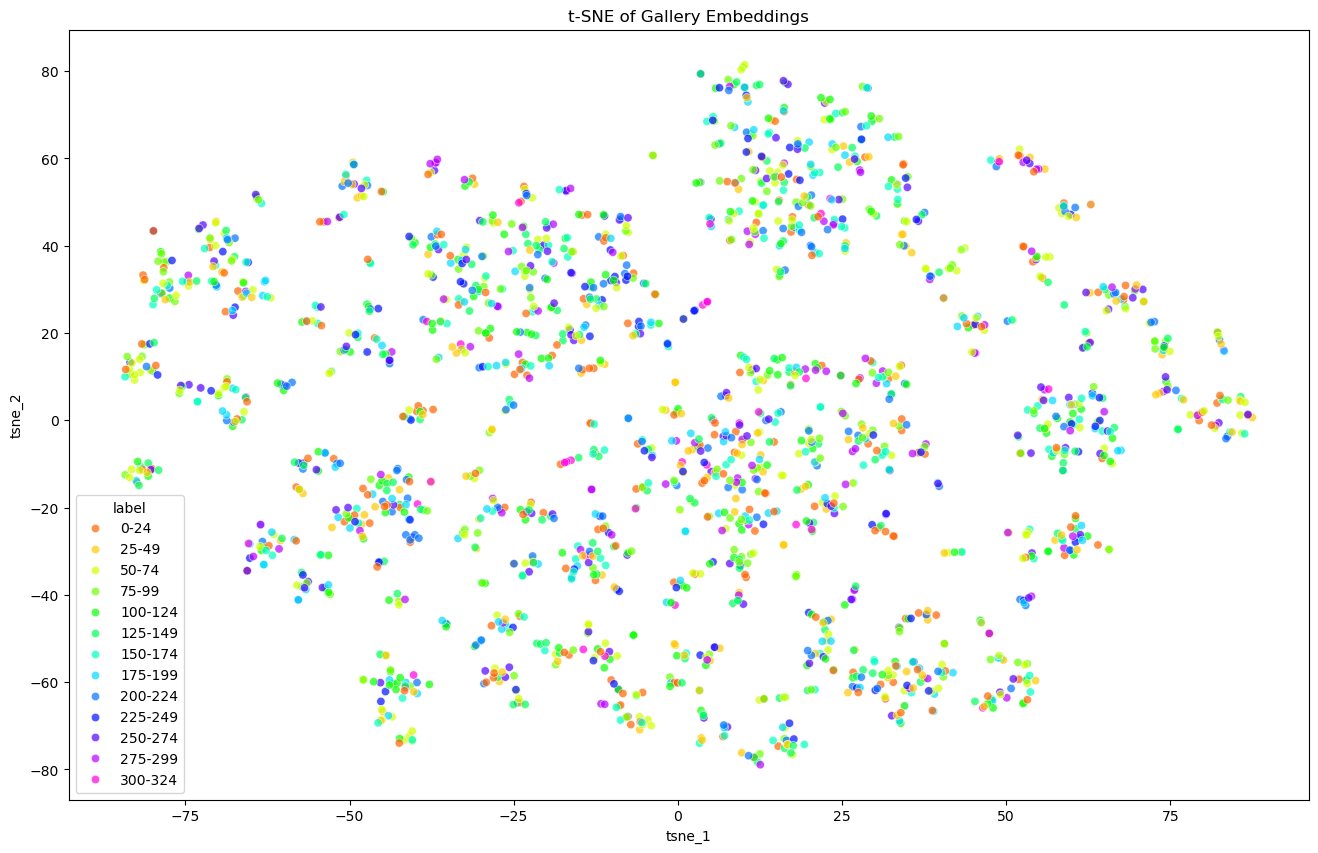

<Figure size 640x480 with 0 Axes>

In [20]:
r = Retrieval(experiment_code=code)
r.evaluate_model(MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=True)

In [22]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.unfreeze()

train_loader = DataLoader(train_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

concept_cat = ConceptHeadTunneled(lr=0.001, loss=categorical_CE_loss, print_every=1, experiment_code = code, layer = MultiHeadNN())
concept_cat.optimizer = Adam(list(concept_cat.layer.parameters()) + list(MD_finetuned.layer.parameters()), lr=1e-5, weight_decay=1e-6)

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)
r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, True  concept head parameters are  True
New record at epoch 1 with val accuracy 0.583513708962571
Epoch 1/20 - Train Loss: 20.1412, Val Loss: 17.9660 - Train Acc: 43.60%, Val Acc: 58.35% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 27.40%, Val left ear: 39.65% - Train right ear: 31.24%, Val right ear: 42.23%
New record at epoch 2 with val accuracy 0.6500918792471999
Epoch 2/20 - Train Loss: 16.9116, Val Loss: 15.2516 - Train Acc: 60.31%, Val Acc: 65.01% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 44.81%, Val left ear: 51.77% - Train right ear: 43.85%, Val right ear: 51.31%
New record at epoch 3 with val accuracy 0.6697894127241203
Epoch 3/20 - Train Loss: 15.2983, Val Loss: 14.6431 - Train Acc: 64.50%, Val Acc: 66.98% - Train whole-code: 0.05%, Val whole-code: 0.07% - Train left ear: 50.00%, Val left ear: 53.23% - Train right ear: 51.10%, Val right ear: 56

100%|██████████| 31/31 [00:12<00:00,  2.46it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.44it/s]


Train Recalls:
Recall@1: 0.50%
Recall@5: 1.67%
Recall@10: 2.78%
Recall@20: 5.25%
Recall@100: 21.61%
Test Recalls:
Recall@1: 0.61%
Recall@5: 2.44%
Recall@10: 3.35%
Recall@20: 6.09%
Recall@100: 22.54%


## Trying to predict the ele_SEEK

In [23]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.unfreeze()

train_loader = DataLoader(train_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

concept_cat = ConceptHeadTunneled(lr=0.001, loss=categorical_CE_loss, print_every=1, experiment_code = code, layer = MultiHeadNN())
concept_cat.optimizer = Adam(list(concept_cat.layer.parameters()) + list(MD_finetuned.layer.parameters()), lr=1e-5, weight_decay=1e-6)

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = True)
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = True)
r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, True  concept head parameters are  True
New record at epoch 1 with val accuracy 0.6901027582408417
Epoch 1/20 - Train Loss: 19.8858, Val Loss: 16.8290 - Train Acc: 45.74%, Val Acc: 69.01% - Train whole-code: 0.00%, Val whole-code: 0.15% - Train left ear: 27.87%, Val left ear: 43.45% - Train right ear: 39.85%, Val right ear: 65.57%
New record at epoch 2 with val accuracy 0.7397665275881687
Epoch 2/20 - Train Loss: 15.0342, Val Loss: 12.5557 - Train Acc: 71.25%, Val Acc: 73.98% - Train whole-code: 0.30%, Val whole-code: 0.00% - Train left ear: 51.98%, Val left ear: 58.15% - Train right ear: 65.21%, Val right ear: 66.61%
New record at epoch 3 with val accuracy 0.7674597544329507
Epoch 3/20 - Train Loss: 12.5742, Val Loss: 11.7178 - Train Acc: 75.70%, Val Acc: 76.75% - Train whole-code: 0.40%, Val whole-code: 0.30% - Train left ear: 64.06%, Val left ear: 66.96% - Train right ear: 66.29%, Val right ear: 6

100%|██████████| 31/31 [00:12<00:00,  2.39it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.42it/s]


Train Recalls:
Recall@1: 0.81%
Recall@5: 2.12%
Recall@10: 3.03%
Recall@20: 5.55%
Recall@100: 23.67%
Test Recalls:
Recall@1: 1.22%
Recall@5: 2.06%
Recall@10: 4.42%
Recall@20: 7.46%
Recall@100: 26.28%


## Crossed-NN (using whole image for ears too)

In [26]:
from torch.optim import Adam
import torch

class CrossedHeadNN(nn.Module):
        def __init__(self):
                super(CrossedHeadNN, self).__init__()

                self.whole_image_layer = nn.Sequential(
                        nn.Linear(768, 768),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(768, 256)
                        ).to('cuda')

                self.left_ear_layer = nn.Sequential(
                        nn.Linear(768, 768),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(768, 256)
                        ).to('cuda')

                self.right_ear_layer = nn.Sequential(
                        nn.Linear(768, 768),
                        nn.LeakyReLU(),
                        nn.Dropout(0.5),
                        nn.Linear(768, 256)
                        ).to('cuda')

                self.heads = {}        
                for key, value in SEEK.lengths.items():
                        if key in ['sex', 'age', 'right_tusk', 'left_tusk', 'right_extreme', 'left_extreme', 'ear_special', 'body_special']: 
                            self.heads[key] = nn.Linear(256, value).to('cuda')
                        elif key in ['R_tear_1', 'R_hole_1', 'R_tear_2', 'R_hole_2', 'L_tear_1', 'L_hole_1', 'L_tear_2', 'L_hole_2']:
                            self.heads[key] = nn.Linear(512, value).to('cuda')
                        else:
                            raise ValueError(f"Unknown key: {key}")

        def forward(self, embeddings):
                whole_image_embeddings = embeddings[:, :768]
                left_ear_embeddings = embeddings[:, 768:1536]
                right_ear_embeddings = embeddings[:, 1536:]

                left_ear_outputs = self.left_ear_layer(left_ear_embeddings)
                right_ear_outputs = self.right_ear_layer(right_ear_embeddings)
                whole_image_outputs = self.whole_image_layer(whole_image_embeddings)

                whole_and_left = torch.cat((whole_image_outputs, left_ear_outputs), dim=1)
                whole_and_right = torch.cat((whole_image_outputs, right_ear_outputs), dim=1)

                outputs = {}
                output_tensor = torch.zeros(embeddings.shape[0], 63).to('cuda')
                idx = 0
                for key, value in SEEK.lengths.items():
                        if key in ['sex', 'age', 'right_tusk', 'left_tusk', 'right_extreme', 'left_extreme', 'ear_special', 'body_special']:
                                outputs[key] = self.heads[key](whole_image_outputs)
                        elif key in ['R_tear_1', 'R_hole_1', 'R_tear_2', 'R_hole_2']:
                                outputs[key] = self.heads[key](whole_and_left)
                        elif key in ['L_tear_1', 'L_hole_1', 'L_tear_2', 'L_hole_2']:
                                outputs[key] = self.heads[key](whole_and_right)
                        else:
                                raise ValueError(f"Unknown key: {key}")
                        
                        output_tensor[:, idx:idx + value] = outputs[key]
                        idx += value

                return output_tensor  # No softmax, CrossEntropyLoss applies it

In [27]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.unfreeze()

train_loader = DataLoader(train_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

concept_cat = ConceptHeadTunneled(lr=0.001, loss=categorical_CE_loss, print_every=1, experiment_code = code, layer = CrossedHeadNN())
concept_cat.optimizer = Adam(list(concept_cat.layer.parameters()) + list(MD_finetuned.layer.parameters()), lr=1e-5, weight_decay=1e-6)

concept_cat.train(train_loader, test_loader, backbone = MD_finetuned, num_epochs=20, predict_ele_SEEK = False)
concept_cat.test(test_loader, backbone = MD_finetuned, predict_ele_SEEK = False)
r = Retrieval(experiment_code=code)

r.evaluate_model(concept_cat, ba=MD_finetuned, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)


Training ConceptHead for 20 epochs, reseting weights, and the backbone parameters are, True  concept head parameters are  True
New record at epoch 1 with val accuracy 0.6390086698035399
Epoch 1/20 - Train Loss: 19.6469, Val Loss: 16.8360 - Train Acc: 47.89%, Val Acc: 63.90% - Train whole-code: 0.05%, Val whole-code: 0.07% - Train left ear: 36.04%, Val left ear: 51.31% - Train right ear: 33.54%, Val right ear: 48.22%
New record at epoch 2 with val accuracy 0.6608030647039413
Epoch 2/20 - Train Loss: 15.8199, Val Loss: 13.9411 - Train Acc: 63.19%, Val Acc: 66.08% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 49.47%, Val left ear: 54.40% - Train right ear: 47.72%, Val right ear: 52.10%
New record at epoch 3 with val accuracy 0.6744636661772218
Epoch 3/20 - Train Loss: 14.1030, Val Loss: 13.2226 - Train Acc: 65.10%, Val Acc: 67.45% - Train whole-code: 0.15%, Val whole-code: 0.07% - Train left ear: 52.25%, Val left ear: 55.76% - Train right ear: 50.76%, Val right ear: 5

100%|██████████| 31/31 [00:12<00:00,  2.41it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.48it/s]


Train Recalls:
Recall@1: 0.66%
Recall@5: 2.22%
Recall@10: 3.28%
Recall@20: 6.06%
Recall@100: 22.11%
Test Recalls:
Recall@1: 0.84%
Recall@5: 1.90%
Recall@10: 2.82%
Recall@20: 5.86%
Recall@100: 23.00%
